# Rollout Simulator Comparison: CV Bottleneck vs Transformer


In [1]:
# Requires: pip install -e .

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from graph_utils import calc_p_ratio_box, calc_p_ratio_rollout_sides

from lss.config import ExperimentConfig
from lss.data import load_dataset, resolve_dataset_splits
from lss.graph import build_graph, rollout
from lss.metrics import evaluate_rollout_pratio_sides
from lss.models import create_model, resolve_model_inputs
from lss.plotting import PAPER_COLORS, apply_editorial_style, paper_caption, style_axes
from lss.runner import run_graph_experiment
from lss.utils import resolve_device

apply_editorial_style()



/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Rollout-first training setup.
# Both models are trained with run_graph_experiment, so checkpoint selection is by rollout p-ratio R2.

force_train = True
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
print('run seed:', seed)

aux_source_path = Path('../../data/data_aux_opt_lowT_448sims_noang_bidirect.pt')
aux_filtered_path = aux_source_path.with_name('data_aux_opt_lowT_448sims_noang_bidirect_filtered.pt')
aux_exclude_sim_indices = []
aux_sims = load_dataset(aux_source_path, edge_multiplicity=1)
aux_keep = [sim for i, sim in enumerate(aux_sims) if i not in set(aux_exclude_sim_indices)]
torch.save(aux_keep, aux_filtered_path)

source_specs = [
    {'name': 'De Pablo', 'path': '../../data/2340_dePablo_networks_OOL_undirected.pt', 'train_count': 20},
    # {'name': 'Reid', 'path': str(aux_filtered_path), 'train_count': 10},
]

cv_count = 40
rollout_steps_for_training = 80
common_cfg = dict(
    dataset_path='mixed',
    dataset_mixture=source_specs,
    shuffle_dataset_within_source=True,
    mix_holdout_across_sources=True,
    output_root='../../results',
    pos_dim=2,
    history=1,
    train_count=sum(int(spec['train_count']) for spec in source_specs),
    val_count=25,
    limit=20,
    hidden_size=128,
    n_layers=1,
    learning_rate=1e-4,
    learning_rate_decay=0.997,
    weight_decay=0.0,
    epochs=20,
    val_every=2,
    rollout_every=2,
    cv_eval_every=0,
    freeze_normalizers_after_epoch=5,
    rollout_steps=rollout_steps_for_training,
    node_features='combined',
    device='cuda',
    seed=seed,
    split_seed=seed,
)

experiment_specs = [
    # {
    #     'label': f'CV bottleneck ({cv_count} CVs, global MLP decoder + local skip)',
    #     'cfg': ExperimentConfig(
    #         run_name=f'rollout_cv{cv_count}_global_mlp5_localskip_acc_rawpos',
    #         model_type='cv_transformer',
    #         model_extras={
    #             'num_mlp': 3,
    #             'transformer_layers': 2,
    #             'transformer_heads': 2,
    #             'transformer_dropout': 0.001,
    #             'token_sizes': (240, 120, cv_count),
    #             'use_normalization': True,
    #             'prediction_target': 'acceleration',
    #             'global_decoder_layers': 3,
    #             'global_decoder_local_skip': True,
    #         },
    #         **common_cfg,
    #     ),
    # },
    {
        'label': 'Classic node TransformerEncoder',
        'cfg': ExperimentConfig(
            run_name='rollout_classic_transformer_acc_combined_noskip',
            model_type='transformer_simulator',
            model_extras={
                'num_mlp': 3,
                'transformer_layers': 2,
                'transformer_heads': 1,
                'transformer_dropout': 0.001,
                'use_normalization': True,
                'prediction_target': 'acceleration',
                'K1': 200,
                'K2': 200,
                'k2_hidden_size': 64,
                'use_local_skip': False,
            },
            **common_cfg,
        ),
    },
    # {
    #     'label': 'Spatial GNN baseline',
    #     'cfg': ExperimentConfig(
    #         run_name='rollout_spatial_gnn_acc_rawpos',
    #         model_type='spatial',
    #         model_extras={
    #             'num_mlp': 3,
    #             'use_skip': False,
    #             'final_decoder_local_skip': False,
    #         },
    #         **common_cfg,
    #     ),
    # },
    # {
    #     'label': 'Spatial GNN final-skip, deeper',
    #     'cfg': ExperimentConfig(
    #         run_name='rollout_spatial_gnn_finalskip_layers5_acc_rawpos',
    #         model_type='spatial',
    #         n_layers=4,
    #         model_extras={
    #             'num_mlp': 3,
    #             'use_skip': False,
    #             'final_decoder_local_skip': True,
    #         },
    #         **{k: v for k, v in common_cfg.items() if k != 'n_layers'},
    #     ),
    # },
]

run_contexts = []
for spec in experiment_specs:
    cfg = spec['cfg']
    run_dir = Path(cfg.output_root) / cfg.run_name
    need_train = force_train or not (run_dir / 'final_checkpoint.pt').exists()
    paper_caption(f"{spec['label']}: training check")
    print('run:', cfg.run_name)
    print('checkpoint:', run_dir / 'final_checkpoint.pt')
    print('training:', need_train)
    if need_train:
        run_graph_experiment(cfg)
    run_contexts.append({'label': spec['label'], 'cfg': cfg, 'run_dir': run_dir})




run seed: 556876017
Classic node TransformerEncoder: training check
run: rollout_classic_transformer_acc_combined_noskip
checkpoint: ../results/rollout_classic_transformer_acc_combined_noskip/final_checkpoint.pt
training: True
[run] rollout_classic_transformer_acc_combined_noskip model=transformer_simulator device=cuda output=../results/rollout_classic_transformer_acc_combined_noskip
[run] training...


/home/alexz/Documents/course_project/src/course_project/models/transformer_simulator.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.node_transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)


[ep   2/20] tr=0.957 va=0.965 lr=9.94e-05 roll=r2=-0.367 p=0.822 mse=4.97e-05 (25/25) t=4.38s
[ep   4/20] tr=0.928 va=0.951 lr=9.88e-05 roll=r2=0.229 p=0.867 mse=4.38e-05 (25/25) t=4.37s
[ep   6/20] tr=0.92 va=0.942 lr=9.82e-05 roll=r2=0.322 p=0.883 mse=4.47e-05 (25/25) t=4.32s
[ep   8/20] tr=0.935 va=0.914 lr=9.76e-05 roll=r2=0.694 p=0.937 mse=8.71e-05 (25/25) t=4.34s
[ep  10/20] tr=0.902 va=0.928 lr=9.7e-05 roll=r2=0.656 p=0.919 mse=4.91e-05 (25/25) t=4.33s
[ep  12/20] tr=0.855 va=0.929 lr=9.65e-05 roll=r2=0.622 p=0.885 mse=3.25e-05 (25/25) t=4.33s
[ep  14/20] tr=0.867 va=0.883 lr=9.59e-05 roll=r2=0.777 p=0.899 mse=2.61e-05 (25/25) t=4.33s
[ep  16/20] tr=0.819 va=0.928 lr=9.53e-05 roll=r2=0.66 p=0.868 mse=3.21e-05 (25/25) t=4.34s
[ep  18/20] tr=0.808 va=0.854 lr=9.47e-05 roll=r2=0.52 p=0.797 mse=3.08e-05 (25/25) t=4.34s
[ep  20/20] tr=0.798 va=0.852 lr=9.42e-05 roll=r2=0.695 p=0.891 mse=4.31e-05 (25/25) t=4.34s
[train] complete in 53.6s
[run] selected checkpoint epoch=14 rollout_r2=0

In [3]:
# Load selected rollout checkpoints and metrics.

for ctx in run_contexts:
    cfg = ctx['cfg']
    run_dir = Path(cfg.output_root) / cfg.run_name
    cfg_dict = json.loads((run_dir / 'config.json').read_text())
    cfg_dict.pop('split_info', None)
    cfg_loaded = ExperimentConfig(**cfg_dict)
    device = resolve_device(cfg_loaded.device)
    model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

    train_data, val_data, test_data, split_info = resolve_dataset_splits(
        cfg_loaded.dataset_path,
        train_count=cfg_loaded.train_count,
        val_count=cfg_loaded.val_count,
        dataset_mixture=cfg_loaded.dataset_mixture,
        split_seed=cfg_loaded.split_seed,
        shuffle_within_source=cfg_loaded.shuffle_dataset_within_source,
        mix_holdout_across_sources=cfg_loaded.mix_holdout_across_sources,
    )

    init_graph = build_graph([val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)], node_features=cfg_loaded.node_features).to(device)
    model = create_model(
        model_type=cfg_loaded.model_type,
        init_graph=init_graph,
        pos_dim=cfg_loaded.pos_dim,
        hidden_size=cfg_loaded.hidden_size,
        n_layers=cfg_loaded.n_layers,
        extras=cfg_loaded.model_extras,
    ).to(device)
    checkpoint = torch.load(run_dir / 'final_checkpoint.pt', map_location='cpu', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    model.freeze_normalizers = True

    stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)
    metrics = json.loads((run_dir / 'metrics.json').read_text())
    ctx.update({
        'cfg_loaded': cfg_loaded,
        'device': device,
        'model_inputs_cls': model_inputs_cls,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data,
        'split_info': split_info,
        'model': model,
        'stats': stats,
        'metrics': metrics,
    })

metrics_df = pd.DataFrame([
    {
        'label': ctx['label'],
        'run_name': ctx['cfg_loaded'].run_name,
        'model_type': ctx['cfg_loaded'].model_type,
        'best_epoch': ctx['metrics'].get('best_epoch'),
        'best_rollout_r2': ctx['metrics'].get('best_score'),
        'final_rollout_r2': ctx['metrics'].get('rollout_r2'),
        'final_rollout_pearson': ctx['metrics'].get('rollout_pearson_r'),
        'final_rollout_pos_mse': ctx['metrics'].get('rollout_pos_mse'),
    }
    for ctx in run_contexts
])
paper_caption('Selected rollout checkpoints')
display(metrics_df.round(6))


Selected rollout checkpoints


,label,run_name,model_type,best_epoch,best_rollout_r2,final_rollout_r2,final_rollout_pearson,final_rollout_pos_mse
0,Classic node TransformerEncoder,rollout_classic_transformer_acc_combined_noskip,transformer_simulator,14,0.777356,0.777356,0.898517,0.000026


Validation rollout during training


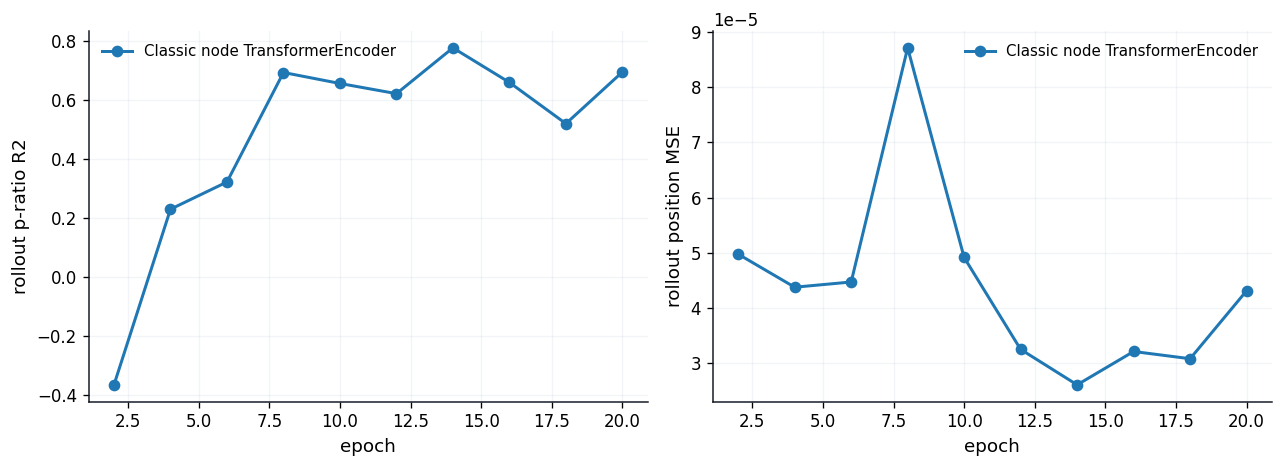

In [4]:
# Training curves: validation rollout R2 and position MSE.

paper_caption('Validation rollout during training')
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0))
for ctx in run_contexts:
    stats = ctx['stats']
    if 'rollout_r2' not in stats:
        continue
    df = pd.DataFrame({
        'epoch': stats['epoch'],
        'rollout_r2': stats['rollout_r2'],
        'rollout_pos_mse': stats['rollout_pos_mse'],
    }).replace([np.inf, -np.inf], np.nan).dropna(subset=['rollout_r2', 'rollout_pos_mse'], how='all')
    axes[0].plot(df['epoch'], df['rollout_r2'], marker='o', lw=1.8, label=ctx['label'])
    axes[1].plot(df['epoch'], df['rollout_pos_mse'], marker='o', lw=1.8, label=ctx['label'])
style_axes(axes[0], xlabel='epoch', ylabel='rollout p-ratio R2', legend=True)
style_axes(axes[1], xlabel='epoch', ylabel='rollout position MSE', legend=True)
plt.tight_layout()
plt.show()


In [5]:
# Evaluate the selected checkpoints at 20 and 80 rollout steps on validation and test.

rows = []
for ctx in run_contexts:
    for split_name, sims in [('val', ctx['val_data']), ('test', ctx['test_data'])]:
        for steps in [20, 80]:
            with torch.no_grad():
                metrics = evaluate_rollout_pratio_sides(
                    model=ctx['model'],
                    sims=sims,
                    history=ctx['cfg_loaded'].history,
                    rollout_steps=steps,
                    pos_dim=ctx['cfg_loaded'].pos_dim,
                    device=ctx['device'],
                    model_inputs_cls=ctx['model_inputs_cls'],
                    node_features=ctx['cfg_loaded'].node_features,
                )
            rows.append({
                'label': ctx['label'],
                'split': split_name,
                'steps': steps,
                'used': metrics['used'],
                'total': metrics['total'],
                'rollout_p_ratio_r2': metrics['rollout_r2'],
                'rollout_p_ratio_pearson': metrics['rollout_pearson_r'],
                'rollout_position_mse': metrics['rollout_pos_mse'],
            })
rollout_eval_df = pd.DataFrame(rows)
paper_caption('Selected-checkpoint rollout evaluation')
display(rollout_eval_df.round(6))


Selected-checkpoint rollout evaluation


,label,split,steps,used,total,rollout_p_ratio_r2,rollout_p_ratio_pearson,rollout_position_mse
0,Classic node TransformerEncoder,val,20,25,25,0.815218,0.926042,0.000001
1,Classic node TransformerEncoder,val,80,25,25,0.777356,0.898517,0.000026
2,Classic node TransformerEncoder,test,20,55,55,0.765374,0.895332,0.000001
3,Classic node TransformerEncoder,test,80,55,55,0.570084,0.800731,0.000034


test rollout p-ratio scatter, 50 steps


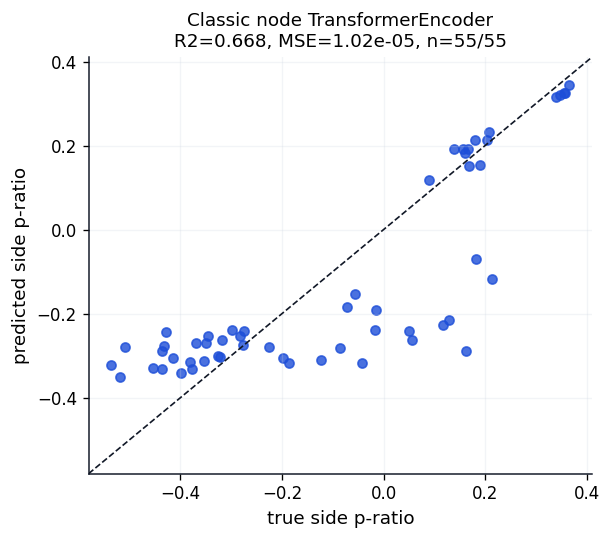

In [6]:
# P-ratio scatter for selected rollout horizon.

scatter_split = 'test'
scatter_steps = 50

paper_caption(f'{scatter_split} rollout p-ratio scatter, {scatter_steps} steps')
fig, axes = plt.subplots(1, len(run_contexts), figsize=(5.2 * len(run_contexts), 4.6), squeeze=False)
all_values = []
scatter_payloads = []
for ctx in run_contexts:
    sims = {'val': ctx['val_data'], 'test': ctx['test_data']}[scatter_split]
    with torch.no_grad():
        metrics = evaluate_rollout_pratio_sides(
            model=ctx['model'],
            sims=sims,
            history=ctx['cfg_loaded'].history,
            rollout_steps=scatter_steps,
            pos_dim=ctx['cfg_loaded'].pos_dim,
            device=ctx['device'],
            model_inputs_cls=ctx['model_inputs_cls'],
            node_features=ctx['cfg_loaded'].node_features,
        )
    rows = pd.DataFrame(metrics['rows'])
    scatter_payloads.append((ctx, metrics, rows))
    if len(rows):
        all_values.extend(rows['target_rollout_sides_p_ratio'].to_numpy(dtype=float))
        all_values.extend(rows['pred_rollout_p_ratio'].to_numpy(dtype=float))

if not all_values:
    raise RuntimeError(f'No usable {scatter_split} trajectories for {scatter_steps}-step rollout scatter.')
lo, hi = float(np.nanmin(all_values)), float(np.nanmax(all_values))
pad = max(0.05 * (hi - lo), 1e-6)
for ax, (ctx, metrics, rows) in zip(axes[0], scatter_payloads):
    if len(rows):
        ax.scatter(
            rows['target_rollout_sides_p_ratio'],
            rows['pred_rollout_p_ratio'],
            s=30,
            alpha=0.80,
            color=PAPER_COLORS['blue'],
        )
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=PAPER_COLORS['ink'], ls='--', lw=1.0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(f"{ctx['label']}\nR2={metrics['rollout_r2']:.3g}, MSE={metrics['rollout_pos_mse']:.3g}, n={metrics['used']}/{metrics['total']}")
    style_axes(ax, xlabel='true side p-ratio', ylabel='predicted side p-ratio')
plt.tight_layout()
plt.show()


80-step sibling-aligned final network comparison


,label,selection,sim_idx,target_index,position_mse,max_error,true_rollout_p_ratio,pred_rollout_p_ratio
0,Classic node TransformerEncoder,auxetic,20,82,0.000041,0.018960,-0.535310,-0.397976
1,Classic node TransformerEncoder,non_auxetic,28,82,0.000007,0.006682,0.366409,0.340247


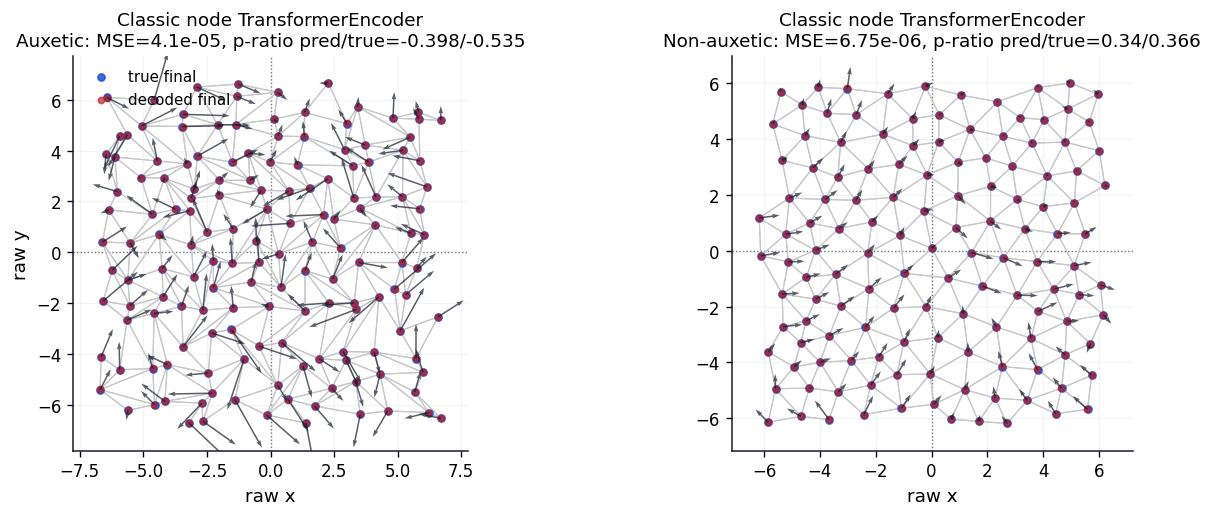

In [7]:
# Visual 80-step rollout comparison on the same test trajectories.

rollout_steps = 80

def box_xy(box):
    if torch.is_tensor(box):
        arr = box.detach().cpu().numpy().reshape(-1)
        return float(arr[0]), float(arr[1])
    if isinstance(box, dict):
        return float(box.get('x', box['x2'] - box['x1'])), float(box.get('y', box['y2'] - box['y1']))
    if hasattr(box, 'x') and hasattr(box, 'y'):
        return float(box.x), float(box.y)
    if hasattr(box, 'x1') and hasattr(box, 'x2') and hasattr(box, 'y1') and hasattr(box, 'y2'):
        return float(box.x2 - box.x1), float(box.y2 - box.y1)
    arr = np.asarray(box, dtype=float).reshape(-1)
    return float(arr[0]), float(arr[1])


def visible_edges(data, pos):
    edge_pairs = data.edge_index.detach().cpu().numpy().T
    box_x, box_y = box_xy(data.box)
    half_x, half_y = 0.5 * box_x, 0.5 * box_y
    keep = []
    for src, dst in edge_pairs:
        dx = abs(float(pos[int(src), 0] - pos[int(dst), 0]))
        dy = abs(float(pos[int(src), 1] - pos[int(dst), 1]))
        if dx <= half_x and dy <= half_y:
            keep.append((int(src), int(dst)))
    return keep


def set_tight_data_limits(ax, x_values, y_values, pad_fraction=0.08):
    def bounds(values):
        arr = np.asarray(values, dtype=float).reshape(-1)
        arr = arr[np.isfinite(arr)]
        lo, hi = float(np.min(arr)), float(np.max(arr))
        pad = max((hi - lo) * pad_fraction, 1e-6) if lo != hi else max(abs(lo) * pad_fraction, 1e-6)
        return lo - pad, hi + pad
    ax.set_xlim(*bounds(x_values))
    ax.set_ylim(*bounds(y_values))


def arrow_scale(pos, vectors, target_fraction=0.18):
    max_norm = float(np.nanmax(np.linalg.norm(vectors[:, :2], axis=1)))
    span = max(float(np.ptp(pos[:, 0])), float(np.ptp(pos[:, 1])), 1.0)
    return 1.0 if max_norm <= 1e-12 else target_fraction * span / max_norm


base_ctx = run_contexts[0]
rollout_prediction_steps = rollout_steps + 1
target_index = base_ctx['cfg_loaded'].history + rollout_prediction_steps
candidates = []
for sim_idx, sim in enumerate(base_ctx['test_data']):
    if len(sim) > target_index:
        candidates.append({'sim_idx': sim_idx, 'final_p_ratio': float(calc_p_ratio_box(sim, -1))})
candidates = pd.DataFrame(candidates)
selected = [
    ('auxetic', candidates.sort_values('final_p_ratio', ascending=True).iloc[0]),
    ('non_auxetic', candidates.sort_values('final_p_ratio', ascending=False).iloc[0]),
]

plot_cases = []
for ctx in run_contexts:
    cfg_local = ctx['cfg_loaded']
    for selection, traj in selected:
        sim = ctx['test_data'][int(traj['sim_idx'])]
        input_graphs = [sim[i] for i in range(cfg_local.history + 1)]
        with torch.no_grad():
            pred_roll = rollout(
                model=ctx['model'],
                input_graphs=input_graphs,
                num_steps=rollout_prediction_steps,
                history=cfg_local.history,
                pos_dim=cfg_local.pos_dim,
                device=ctx['device'],
                model_inputs_cls=ctx['model_inputs_cls'],
                node_features=ctx['cfg_loaded'].node_features,
            )
        true_graph = sim[target_index]
        true_pos = true_graph.x[:, : cfg_local.pos_dim].detach().cpu().numpy()
        pred_pos = pred_roll[-1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
        delta = pred_pos - true_pos
        plot_cases.append({
            'label': ctx['label'],
            'selection': selection,
            'sim_idx': int(traj['sim_idx']),
            'target_index': target_index,
            'true_pos': true_pos,
            'pred_pos': pred_pos,
            'delta': delta,
            'edges': visible_edges(true_graph, true_pos),
            'position_mse': float(np.mean(delta[:, : cfg_local.pos_dim] ** 2)),
            'max_error': float(np.max(np.linalg.norm(delta[:, :2], axis=1))),
            'true_rollout_p_ratio': float(calc_p_ratio_rollout_sides(sim, target_index)),
            'pred_rollout_p_ratio': float(calc_p_ratio_rollout_sides(pred_roll, -1)),
        })

summary = pd.DataFrame([
    {k: v for k, v in case.items() if k not in {'true_pos', 'pred_pos', 'delta', 'edges'}}
    for case in plot_cases
])
paper_caption(f'{rollout_steps}-step sibling-aligned final network comparison')
display(summary.round(6))

all_pos = np.vstack([np.vstack([case['true_pos'][:, :2], case['pred_pos'][:, :2]]) for case in plot_cases])
all_delta = np.vstack([case['delta'][:, :2] for case in plot_cases])
error_scale = arrow_scale(all_pos, all_delta)

fig, axes = plt.subplots(len(run_contexts), 2, figsize=(11.0, 4.2 * len(run_contexts)), squeeze=False, constrained_layout=True)
case_lookup = {(case['label'], case['selection']): case for case in plot_cases}
for row_idx, ctx in enumerate(run_contexts):
    for col_idx, selection in enumerate(['auxetic', 'non_auxetic']):
        ax = axes[row_idx, col_idx]
        case = case_lookup[(ctx['label'], selection)]
        true_pos = case['true_pos']
        pred_pos = case['pred_pos']
        for src, dst in case['edges']:
            ax.plot([true_pos[src, 0], true_pos[dst, 0]], [true_pos[src, 1], true_pos[dst, 1]], color='0.78', lw=0.7, zorder=1)
        ax.scatter(true_pos[:, 0], true_pos[:, 1], s=18, color=PAPER_COLORS['blue'], alpha=0.85, label='true final', zorder=2)
        ax.scatter(pred_pos[:, 0], pred_pos[:, 1], s=14, color=PAPER_COLORS['red'], alpha=0.65, label='decoded final', zorder=3)
        err = case['delta'][:, :2] * error_scale
        ax.quiver(true_pos[:, 0], true_pos[:, 1], err[:, 0], err[:, 1], angles='xy', scale_units='xy', scale=1.0, color=PAPER_COLORS['ink'], width=0.0038, alpha=0.70, zorder=4)
        ax.axhline(0.0, color='0.35', lw=0.8, ls=':', zorder=0)
        ax.axvline(0.0, color='0.35', lw=0.8, ls=':', zorder=0)
        set_tight_data_limits(ax, np.r_[true_pos[:, 0], pred_pos[:, 0]], np.r_[true_pos[:, 1], pred_pos[:, 1]])
        ax.set_aspect('equal', adjustable='box')
        title = 'Auxetic' if selection == 'auxetic' else 'Non-auxetic'
        ax.set_title(f"{ctx['label']}\n{title}: MSE={case['position_mse']:.3g}, p-ratio pred/true={case['pred_rollout_p_ratio']:.3g}/{case['true_rollout_p_ratio']:.3g}")
        style_axes(ax, xlabel='raw x', ylabel='raw y' if col_idx == 0 else None, legend=(row_idx == 0 and col_idx == 0))
plt.show()
